In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

result_path = os.getcwd()
within_group_comparison_path = os.path.join(result_path, 'within_group')
between_group_comparison_path = os.path.join(result_path, 'between_group')


def visualize_comparison_boxplot(trial_id: str, metric_column: str):
    """
    比较不同组在特定指标上的表现
    """
    path_with_trial = os.path.join(within_group_comparison_path, f'trial_{trial_id}')
    group_files = [f for f in os.listdir(path_with_trial) if f.endswith(".csv")]
    
    all_data = []
    group_names = []
    
    for group_file in group_files:
        group_path = os.path.join(path_with_trial, group_file)
        df = pd.read_csv(group_path)
        df_trial = df[df['trial_id'] == int(trial_id)]
        
        if metric_column in df_trial.columns:
            group_name = group_file.replace(".csv", "")
            all_data.extend(df_trial[metric_column].dropna().tolist())
            group_names.extend([group_name] * len(df_trial[metric_column].dropna()))
    
    if all_data:
        # 创建DataFrame用于seaborn
        comparison_df = pd.DataFrame({
            'Group': group_names,
            metric_column: all_data
        })
        
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=comparison_df, x='Group', y=metric_column)
        plt.title(f'Comparison of {metric_column} across Groups - Trial {trial_id}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data found for metric '{metric_column}' in trial {trial_id}")

# 示例调用
# visualize_within_group_boxplot('2')
# visualize_comparison_boxplot('2', 'your_metric_column_name')


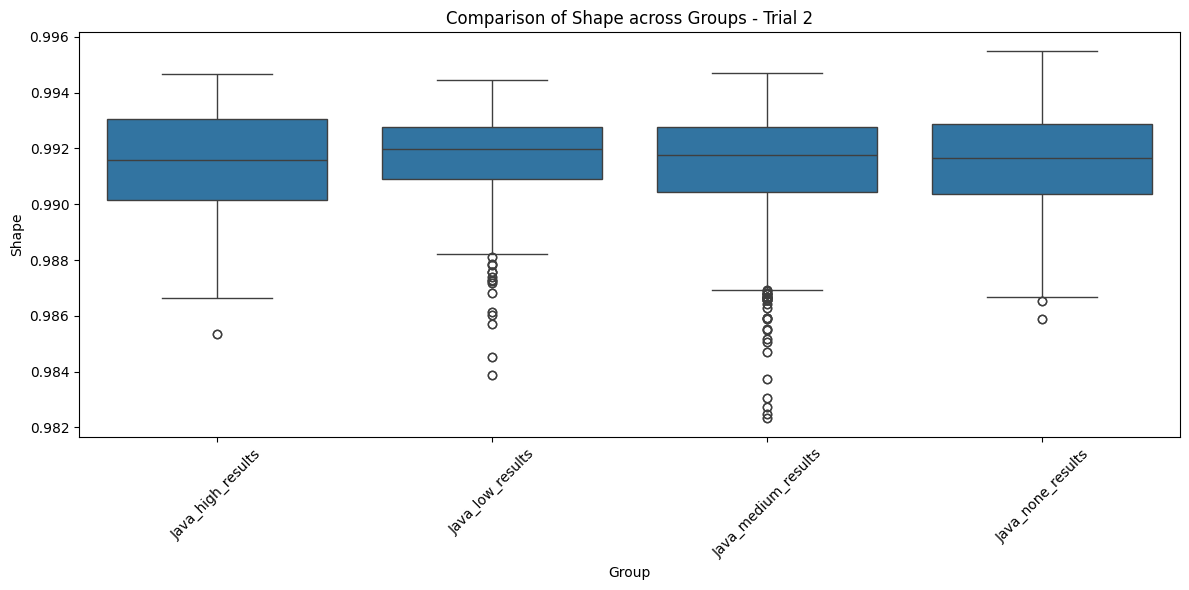

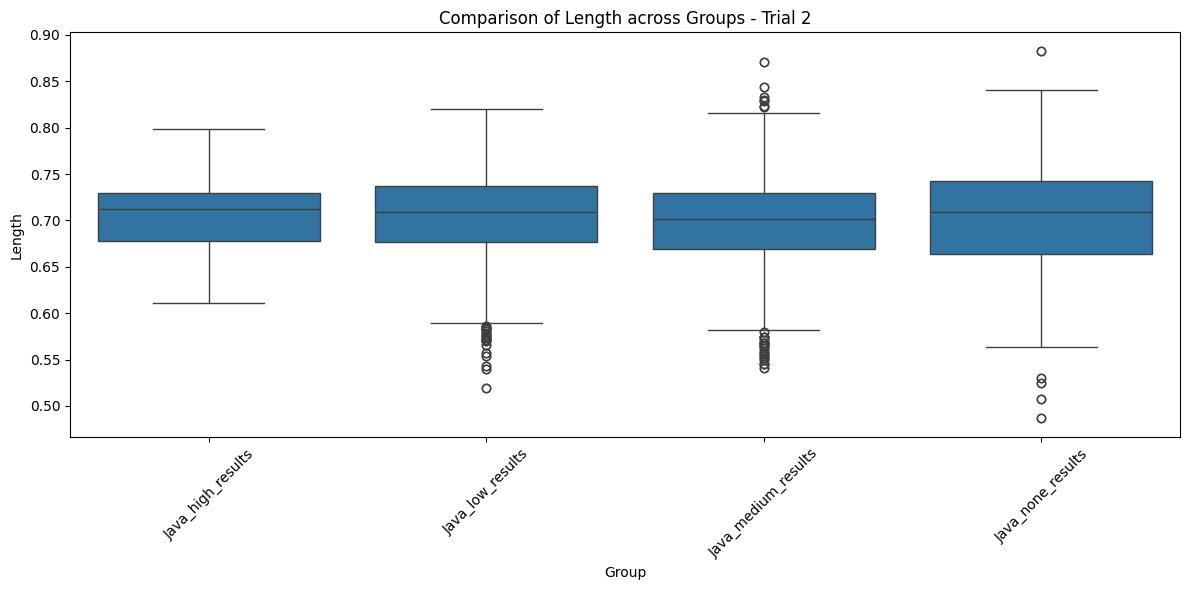

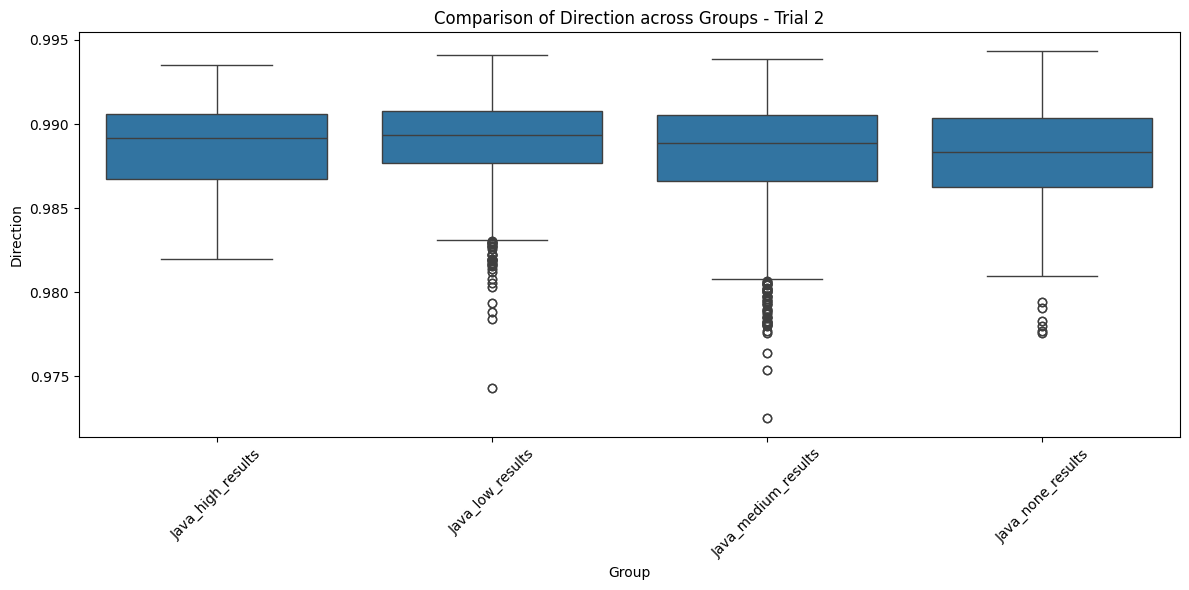

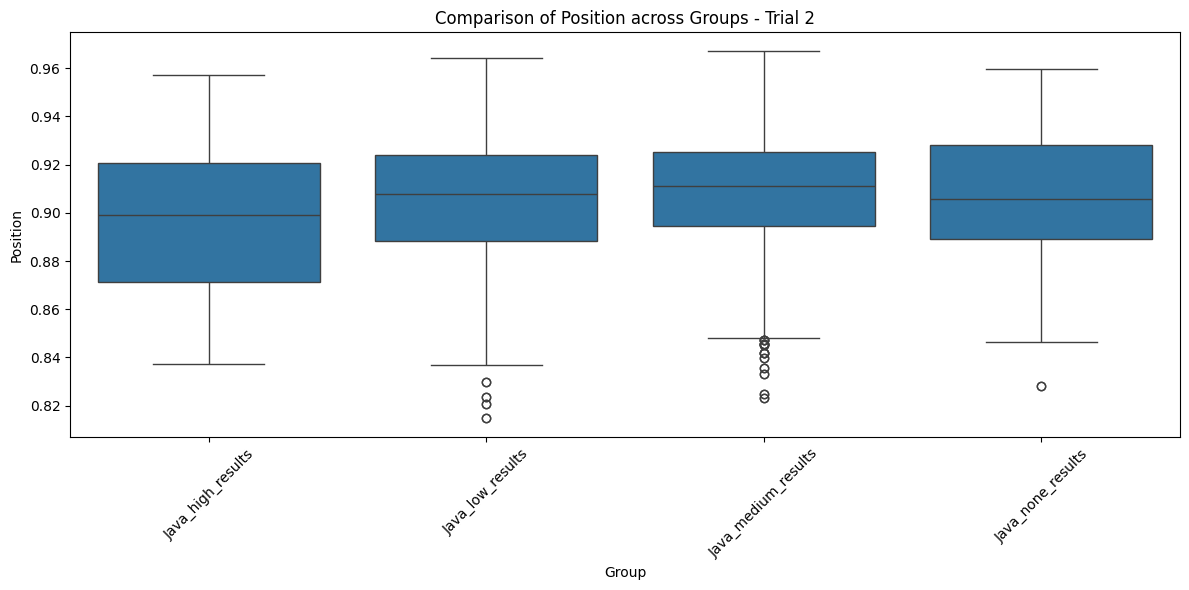

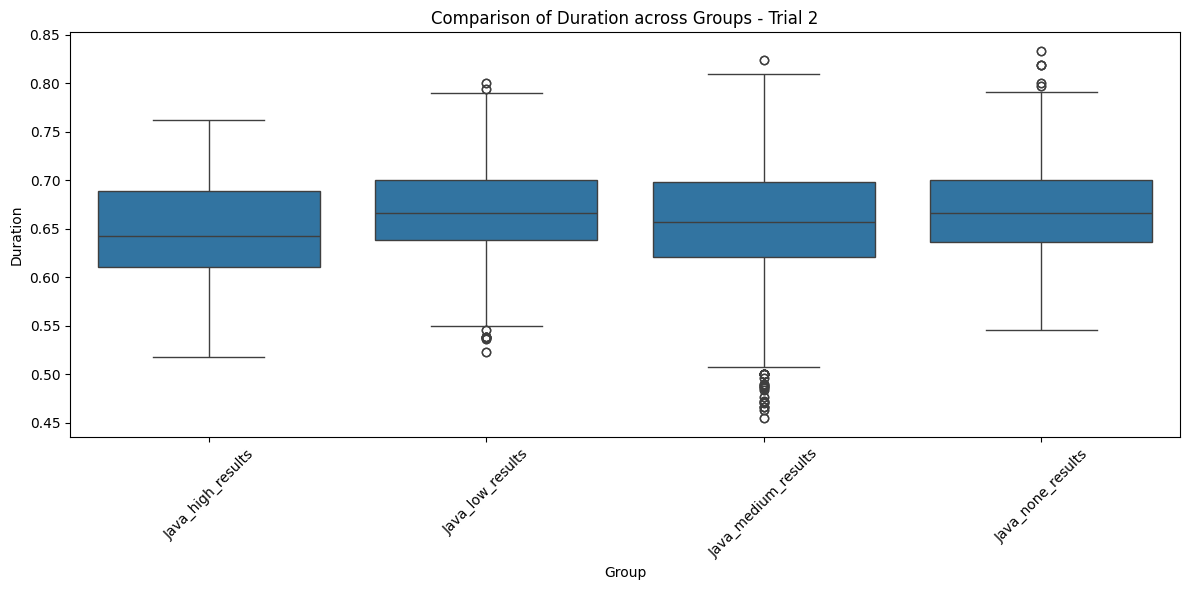

In [2]:
metrics = ['Shape', 'Length', 'Direction', 'Position', 'Duration']

for metric in metrics:
    visualize_comparison_boxplot('2', metric)